In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

ModuleNotFoundError: No module named 'kagglehub'

In [1]:
import pandas as pd

df = pd.read_excel(
    "cleaned_vrinda_store_data.xlsx"
)

df.head()

,order_index,order_id,cust_id,gender,age,date,status,channel,sku,category,size,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b
0,1,171-1029312-3038738,1029312,Women,44,2022-12-04,Delivered,Myntra,JNE1233-BLUE-KR-031-XXL,kurta,XXL,1,INR,376,MOHALI,PUNJAB,140301,IN,False
1,2,405-2183842-2225946,2183842,Women,29,2022-12-04,Delivered,Ajio,SET414-KR-NP-L,Set,L,1,INR,1449,GURUGRAM,HARYANA,122002,IN,False
2,3,171-1641533-8921966,1641533,Women,67,2022-12-04,Delivered,Myntra,SET261-KR-PP-S,Set,S,1,INR,453,KOLKATA,WEST BENGAL,700029,IN,False
3,4,404-7490807-6300351,7490807,Women,20,2022-12-04,Delivered,Amazon,SET110-KR-PP-M,Set,M,1,INR,729,THANJAVUR,TAMIL NADU,613007,IN,False
4,5,403-9293516-4577154,9293516,Women,62,2022-12-04,Delivered,Myntra,JNE2294-KR-A-XXL,kurta,XXL,1,INR,544,GURUGRAM,HARYANA,122001,IN,False


In [8]:
print("Shape :", df.shape)

print("\nColumn Names\n")
print(df.columns.tolist())

print("\n")
df.info()

Shape : (31047, 19)

Column Names

['order_index', 'order_id', 'cust_id', 'gender', 'age', 'date', 'status', 'channel', 'sku', 'category', 'size', 'qty', 'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'ship_country', 'b2b']


<class 'pandas.DataFrame'>
RangeIndex: 31047 entries, 0 to 31046
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_index       31047 non-null  int64         
 1   order_id          31047 non-null  str           
 2   cust_id           31047 non-null  int64         
 3   gender            31047 non-null  str           
 4   age               31047 non-null  int64         
 5   date              31047 non-null  datetime64[us]
 6   status            31047 non-null  str           
 7   channel           31047 non-null  str           
 8   sku               31047 non-null  str           
 9   category          31047 non-null  str           
 10  s

In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

missing

,Missing Values,Percentage
order_index,0,0.0
order_id,0,0.0
cust_id,0,0.0
gender,0,0.0
age,0,0.0
date,0,0.0
status,0,0.0
channel,0,0.0
sku,0,0.0
category,0,0.0


In [10]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [11]:
for col in df.columns:
    print("="*60)
    print(col)
    print("Unique Values :", df[col].nunique())

    if df[col].nunique() <= 20:
        print(df[col].value_counts())

    print()

order_index
Unique Values : 31047

order_id
Unique Values : 28471

cust_id
Unique Values : 28437

gender
Unique Values : 2
gender
Women    21553
Men       9494
Name: count, dtype: int64

age
Unique Values : 61

date
Unique Values : 36

status
Unique Values : 4
status
Delivered    28641
Returned      1045
Cancelled      844
Refunded       517
Name: count, dtype: int64

channel
Unique Values : 7
channel
Amazon      11016
Myntra       7254
Flipkart     6703
Ajio         1931
Nalli        1484
Meesho       1398
Others       1261
Name: count, dtype: int64

sku
Unique Values : 5287

category
Unique Values : 8
category
Set              12391
kurta            10446
Western Dress     4066
Top               2193
Saree             1380
Ethnic Dress       264
Blouse             229
Bottom              78
Name: count, dtype: int64

size
Unique Values : 11
size
M       5485
L       5144
XL      4437
S       4176
XXL     4065
3XL     3347
XS      2503
Free    1408
6XL      208
5XL      161
4XL      1

In [16]:
print("Unique Orders :", df["order_id"].nunique())
print("Total Rows :", len(df))

print("\nAverage Items per Order :",
      round(len(df)/df["order_id"].nunique(),2))

Unique Orders : 28471
Total Rows : 31047

Average Items per Order : 1.09


In [17]:
order_items = df.groupby("order_id").size()

order_items.value_counts().sort_index()

1     26407
2      1718
3       247
4        63
5        24
6         5
7         3
8         1
9         1
11        1
12        1
Name: count, dtype: int64

In [18]:
df["Year"] = df["date"].dt.year
df["Month_Number"] = df["date"].dt.month
df["Weekday"] = df["date"].dt.day_name()

df.head()

,order_index,order_id,cust_id,gender,age,date,status,channel,sku,category,...,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,Year,Month_Number,Weekday
0,1,171-1029312-3038738,1029312,Women,44,2022-12-04,Delivered,Myntra,JNE1233-BLUE-KR-031-XXL,kurta,...,INR,376,MOHALI,PUNJAB,140301,IN,False,2022,12,Sunday
1,2,405-2183842-2225946,2183842,Women,29,2022-12-04,Delivered,Ajio,SET414-KR-NP-L,Set,...,INR,1449,GURUGRAM,HARYANA,122002,IN,False,2022,12,Sunday
2,3,171-1641533-8921966,1641533,Women,67,2022-12-04,Delivered,Myntra,SET261-KR-PP-S,Set,...,INR,453,KOLKATA,WEST BENGAL,700029,IN,False,2022,12,Sunday
3,4,404-7490807-6300351,7490807,Women,20,2022-12-04,Delivered,Amazon,SET110-KR-PP-M,Set,...,INR,729,THANJAVUR,TAMIL NADU,613007,IN,False,2022,12,Sunday
4,5,403-9293516-4577154,9293516,Women,62,2022-12-04,Delivered,Myntra,JNE2294-KR-A-XXL,kurta,...,INR,544,GURUGRAM,HARYANA,122001,IN,False,2022,12,Sunday


In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_index,31047.0,15524.0,1.0,7762.5,15524.0,23285.5,31047.0,8962.64124
cust_id,31047.0,4936823.827874,895.0,2416471.0,4909885.0,7454181.5,9999233.0,2900677.94835
age,31047.0,39.49657,18.0,28.0,37.0,47.0,78.0,15.117233
date,31047,2022-06-15 06:41:39.719779,2022-01-04 00:00:00,2022-03-06 00:00:00,2022-06-06 00:00:00,2022-09-06 00:00:00,2022-12-06 00:00:00,NaN
qty,31047.0,1.00612,1.0,1.0,1.0,1.0,5.0,0.094088
amount,31047.0,682.074822,229.0,486.0,646.0,794.0,3036.0,268.582173
ship_postal_code,31047.0,460474.587206,110001.0,313001.0,500028.0,600040.0,855117.0,198116.733009
Year,31047.0,2022.0,2022.0,2022.0,2022.0,2022.0,2022.0,0.0
Month_Number,31047.0,6.329951,1.0,3.0,6.0,9.0,12.0,3.436028


In [22]:
df.describe(include="object").T


C:\Users\my\AppData\Local\Temp\ipykernel_11332\3164331651.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
order_id,31047,28471,403-4984515-8861958,12
gender,31047,2,Women,21553
status,31047,4,Delivered,28641
channel,31047,7,Amazon,11016
sku,31047,5287,JNE3797-KR-L,273
category,31047,8,Set,12391
size,31047,11,M,5485
currency,31047,1,INR,31047
ship_city,31047,2603,BENGALURU,2540
ship_state,31047,50,MAHARASHTRA,4519


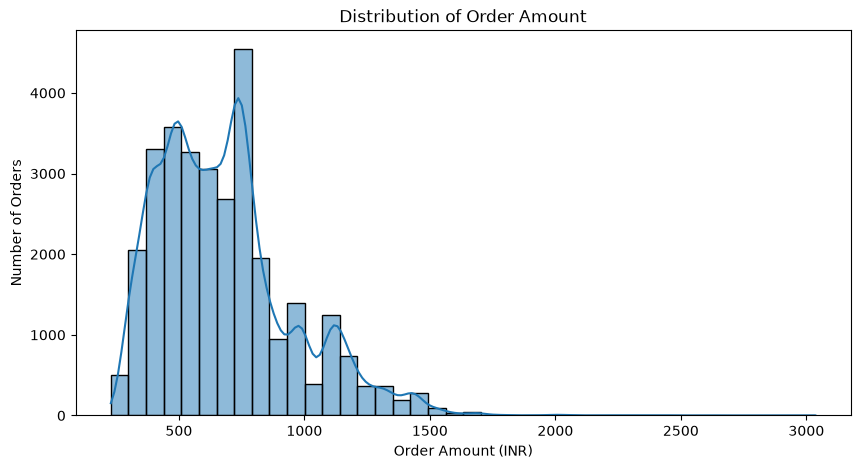

In [24]:

# !pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    df["amount"],
    bins=40,
    kde=True
)

plt.title("Distribution of Order Amount")
plt.xlabel("Order Amount (INR)")
plt.ylabel("Number of Orders")

plt.show()

In [26]:
print(df["amount"].describe())

count    31047.000000
mean       682.074822
std        268.582173
min        229.000000
25%        486.000000
50%        646.000000
75%        794.000000
max       3036.000000
Name: amount, dtype: float64


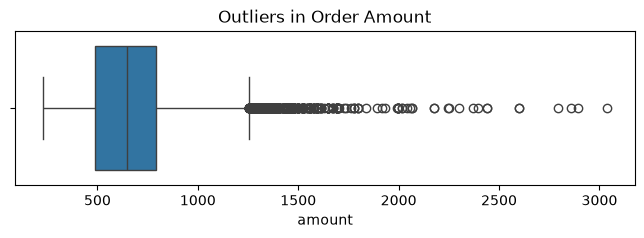

In [27]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["amount"]
)

plt.title("Outliers in Order Amount")

plt.show()

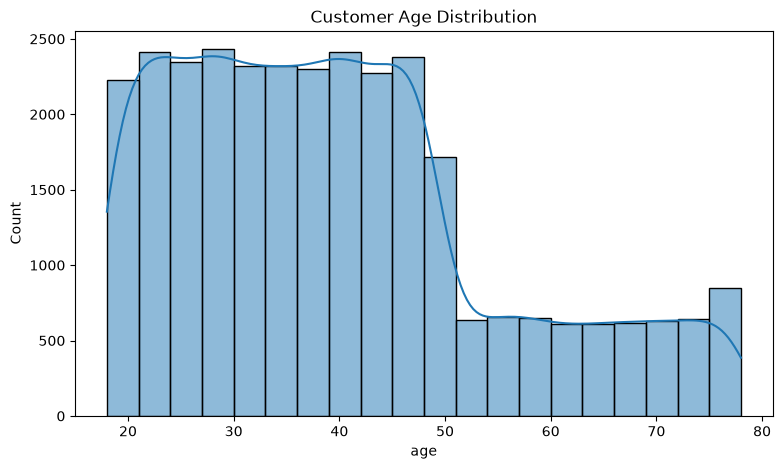

In [28]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("age")

plt.show()

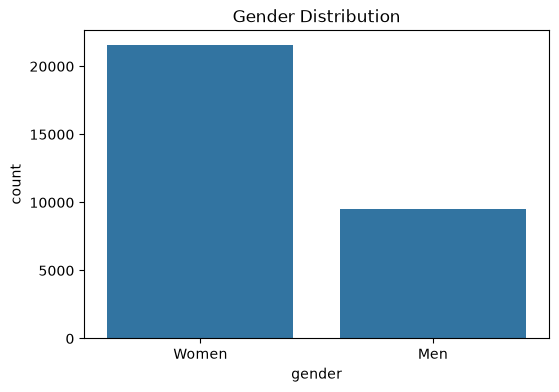

gender
Women    69.420556
Men      30.579444
Name: proportion, dtype: float64


In [33]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

print(df["gender"].value_counts(normalize=True)*100)

In [47]:
# monthly_sales = (
#     df.groupby("date")["amount"]
#       .sum()
#       .reset_index()
# )

# month_order = [
#     "Jan","Feb","Mar","Apr","May","Jun",
#     "Jul","Aug","Sep","Oct","Nov","Dec"
# ]

# monthly_sales["date"] = pd.Categorical(
#     monthly_sales["date"],
#     categories=month_order,
#     ordered=True
# )

# monthly_sales = monthly_sales.sort_values("date")

# monthly_sales


# 1. Date column se month name nikaalo (Jan, Feb, Mar...)
df['Month'] = df['date'].dt.strftime('%b') 

# 2. Month order define karo
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# 3. Group karo aur reindex se sort karo
monthly_sales = (
    df.groupby('Month')['amount']
      .sum()
      .reindex(month_order)
      .reset_index()
)

monthly_sales



# # 1. Month name extract karo
# df['Month'] = df['date'].dt.strftime('%b')

# # 2. Group karo
# monthly_sales = (
#     df.groupby("Month")["amount"]
#       .sum()
#       .reset_index()
# )

# # 3. Month order define karo
# month_order = ["Jan","Feb","Mar","Apr","May","Jun",
#                "Jul","Aug","Sep","Oct","Nov","Dec"]

# # 4. Categorical banao aur sort karo
# monthly_sales["Month"] = pd.Categorical(
#     monthly_sales["Month"],
#     categories=month_order,
#     ordered=True
# )

# monthly_sales = monthly_sales.sort_values("Month")

# monthly_sales

,Month,amount
0,Jan,1820601
1,Feb,1875932
2,Mar,1928066
3,Apr,1829263
4,May,1797822
5,Jun,1750966
6,Jul,1772300
7,Aug,1808505
8,Sep,1688871
9,Oct,1666662


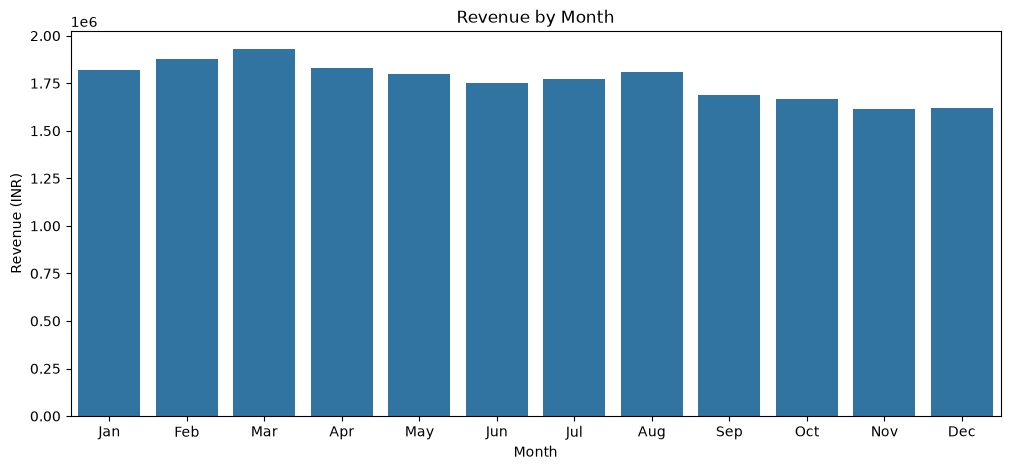

In [49]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_sales,
    x="Month",
    y="amount"
)

plt.title("Revenue by Month")
plt.ylabel("Revenue (INR)")

plt.show()

In [50]:
monthly_sales

,Month,amount
0,Jan,1820601
1,Feb,1875932
2,Mar,1928066
3,Apr,1829263
4,May,1797822
5,Jun,1750966
6,Jul,1772300
7,Aug,1808505
8,Sep,1688871
9,Oct,1666662


In [53]:
monthly_orders = (
    df.groupby("Month")["order_id"]
      .nunique()
      .reset_index(name="Orders")
)

monthly_orders["Month"] = pd.Categorical(
    monthly_orders["Month"],
    categories=month_order,
    ordered=True
)

monthly_orders = monthly_orders.sort_values("Month")

monthly_orders

,Month,Orders
4,Jan,2461
3,Feb,2503
7,Mar,2599
0,Apr,2480
8,May,2401
6,Jun,2372
5,Jul,2340
1,Aug,2404
11,Sep,2278
10,Oct,2234


Task was destroyed but it is pending!
task: <Task pending name='Task-284' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-285' coro=<Kernel.shell_main() running at C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_api\__init__.py:123: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def check_isinstance(types, /, **kwargs):
Task was destroyed but it is pending!
task: <Task pending name='Task-285' coro=<Kernel.shell_main() running at C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelba

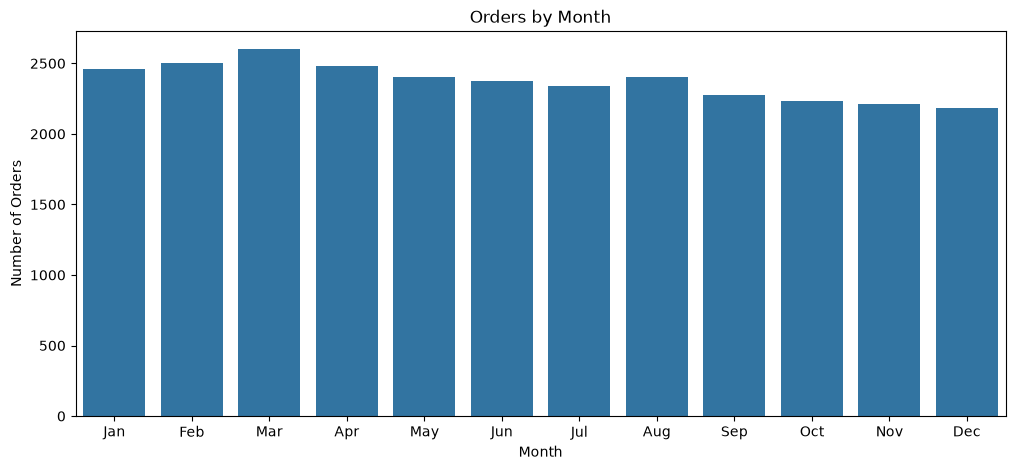

Index(['Month', 'Orders'], dtype='str')
  Month  Orders
4   Jan    2461
3   Feb    2503
7   Mar    2599
0   Apr    2480
8   May    2401


In [58]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_orders,
    x="Month",
    y="Orders"
)

plt.title("Orders by Month")
plt.ylabel("Number of Orders")

plt.show()



print(monthly_orders.columns)
print(monthly_orders.head())

In [63]:
monthly_analysis = (
    df.groupby("Month")
      .agg(
          Revenue=("amount","sum"),
          Orders=("order_id","nunique")
      )
      .reset_index()
)

monthly_analysis["Month"] = pd.Categorical(
    monthly_analysis["Month"],
    categories=month_order,
    ordered=True
)

monthly_analysis = monthly_analysis.sort_values("Month")

monthly_analysis["Average_Order_Value"] = (
    monthly_analysis["Revenue"] /
    monthly_analysis["Orders"]
)

monthly_analysis




# print(monthly_orders.columns)
# print(monthly_orders.head())

,Month,Revenue,Orders,Average_Order_Value
4,Jan,1820601,2461,739.780983
3,Feb,1875932,2503,749.473432
7,Mar,1928066,2599,741.849173
0,Apr,1829263,2480,737.606048
8,May,1797822,2401,748.780508
6,Jun,1750966,2372,738.181282
5,Jul,1772300,2340,757.393162
1,Aug,1808505,2404,752.289933
11,Sep,1688871,2278,741.383231
10,Oct,1666662,2234,746.043868


In [56]:
print("""Business Insight 1
March generated the highest revenue because it also had the highest number of orders (2,599). This indicates that revenue growth was primarily driven by increased sales volume rather than higher spending per customer.

Business Insight 2
November had the lowest revenue and also one of the lowest order counts. This suggests that reduced customer demand, rather than lower product pricing, was the primary reason for weaker sales.

Business Insight 3
Average Order Value remains remarkably stable throughout the year (₹730–₹757). Since customers spend nearly the same amount per order each month, fluctuations in revenue are mainly due to changes in the number of orders rather than basket size.

This is a strong business observation because it tells management where to focus:

Increase customer traffic/orders, not necessarily increase prices.""")

Business Insight 1
March generated the highest revenue because it also had the highest number of orders (2,599). This indicates that revenue growth was primarily driven by increased sales volume rather than higher spending per customer.

Business Insight 2
November had the lowest revenue and also one of the lowest order counts. This suggests that reduced customer demand, rather than lower product pricing, was the primary reason for weaker sales.

Business Insight 3
Average Order Value remains remarkably stable throughout the year (₹730–₹757). Since customers spend nearly the same amount per order each month, fluctuations in revenue are mainly due to changes in the number of orders rather than basket size.

This is a strong business observation because it tells management where to focus:

Increase customer traffic/orders, not necessarily increase prices.


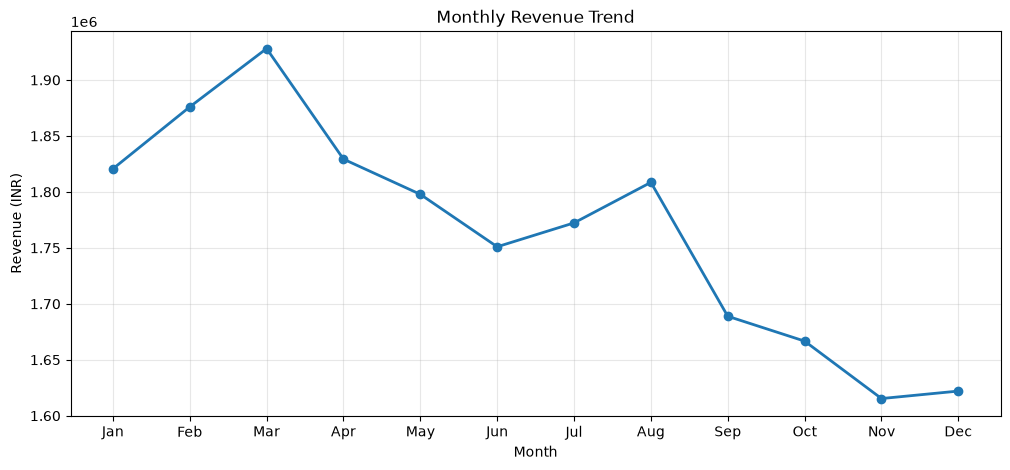

In [64]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.grid(alpha=0.3)

plt.show()

In [65]:
print("""Interpretation
Revenue peaked in March (₹19.28 Lakhs).

March generated the highest monthly revenue.

It also had the highest number of orders (2,599), indicating strong customer demand.

Steady decline after March.

Revenue gradually decreased from April onward.

A brief recovery occurred in August before declining again.

Weak fourth quarter (Sep–Dec).

September marked the beginning of a sustained revenue decline.

November recorded the lowest revenue (₹16.15 Lakhs), around 16% lower than March.

Let's calculate that:

((19.28−16.15)/19.28)×100≈16.2%

So you can confidently mention:

Revenue declined by approximately 16% from the yearly peak (March) to the lowest-performing month (November).

Business Insight
Revenue fluctuations closely mirror the number of orders while the Average Order Value remains relatively stable throughout the year. This indicates that the decline in revenue during the second half of the year is primarily due to fewer customer purchases rather than customers spending less per order.

Business Problem Identified
This visualization directly supports one business problem:

The business experiences a noticeable decline in customer demand after March, leading to a 16% reduction in monthly revenue by November. Management needs strategies to maintain customer acquisition and repeat purchases during the second half of the year.

This is much stronger than simply saying "sales decreased.""")

Interpretation
Revenue peaked in March (₹19.28 Lakhs).

March generated the highest monthly revenue.

It also had the highest number of orders (2,599), indicating strong customer demand.

Steady decline after March.

Revenue gradually decreased from April onward.

A brief recovery occurred in August before declining again.

Weak fourth quarter (Sep–Dec).

September marked the beginning of a sustained revenue decline.

November recorded the lowest revenue (₹16.15 Lakhs), around 16% lower than March.

Let's calculate that:

((19.28−16.15)/19.28)×100≈16.2%

So you can confidently mention:

Revenue declined by approximately 16% from the yearly peak (March) to the lowest-performing month (November).

Business Insight
Revenue fluctuations closely mirror the number of orders while the Average Order Value remains relatively stable throughout the year. This indicates that the decline in revenue during the second half of the year is primarily due to fewer customer purchases rather than customers

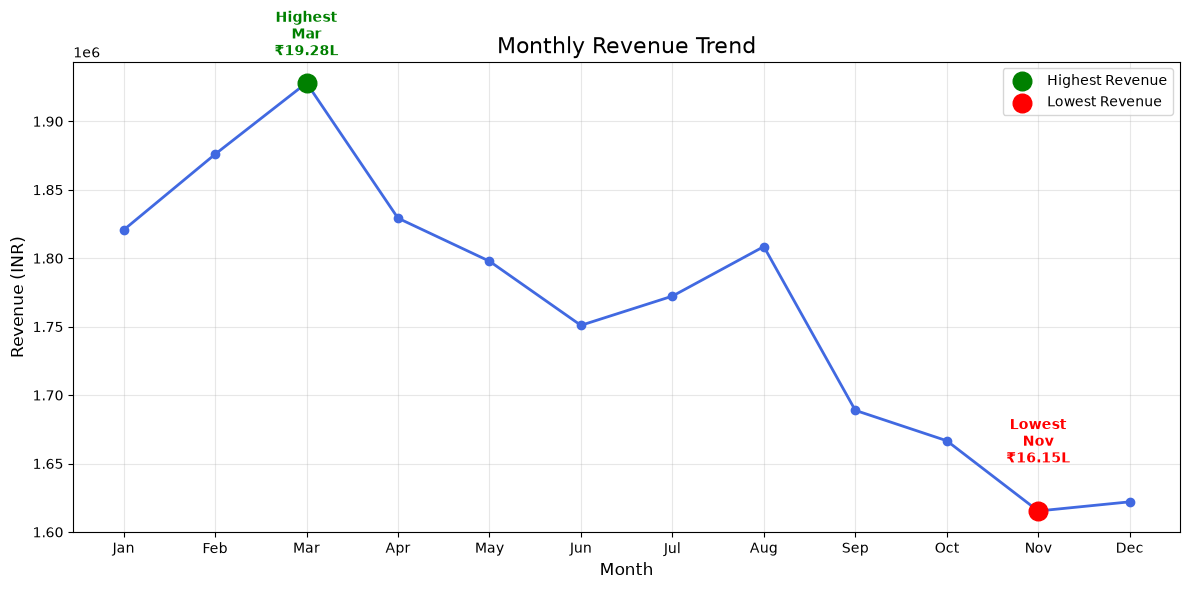

In [66]:
import matplotlib.pyplot as plt

# Ensure months are in calendar order
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_analysis["Month"] = pd.Categorical(
    monthly_analysis["Month"],
    categories=month_order,
    ordered=True
)

monthly_analysis = monthly_analysis.sort_values("Month").reset_index(drop=True)

# Get highest and lowest revenue rows
max_idx = monthly_analysis["Revenue"].idxmax()
min_idx = monthly_analysis["Revenue"].idxmin()

plt.figure(figsize=(12,6))

# Revenue trend
plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Revenue"],
    marker="o",
    linewidth=2,
    color="royalblue"
)

# Highlight highest revenue
plt.scatter(
    monthly_analysis.loc[max_idx, "Month"],
    monthly_analysis.loc[max_idx, "Revenue"],
    color="green",
    s=180,
    label="Highest Revenue",
    zorder=5
)

# Highlight lowest revenue
plt.scatter(
    monthly_analysis.loc[min_idx, "Month"],
    monthly_analysis.loc[min_idx, "Revenue"],
    color="red",
    s=180,
    label="Lowest Revenue",
    zorder=5
)

plt.annotate(
    f"Highest\nMar\n₹{monthly_analysis.loc[max_idx,'Revenue']/100000:.2f}L",
    xy=(max_idx, monthly_analysis.loc[max_idx,"Revenue"]),
    xytext=(0,20),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    color="green",
    fontweight="bold"
)

plt.annotate(
    f"Lowest\nNov\n₹{monthly_analysis.loc[min_idx,'Revenue']/100000:.2f}L",
    xy=(min_idx, monthly_analysis.loc[min_idx,"Revenue"]),
    xytext=(0,35),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    color="red",
    fontweight="bold"
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (INR)", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()